In [60]:
import joblib
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

la ley de demanda dice que si subo el precio de un bien baja la demanda y lo mismo al revez, primero hay que comprobar que el modelo aprendio bien esto con el avg price como precio y el volumen como demanda

In [61]:
BASE_DIR = os.getcwd() 
DATA_PATH = os.path.join('..', 'data', 'avocado_processed_city.csv')
MODEL_PATH = os.path.join('..', 'models', 'xgb_avocado_LosAngeles.pkl')
model = joblib.load(MODEL_PATH)


In [62]:
# inventar datos para prueba del modelo pero sin volumen
bajo = pd.DataFrame({'AVGPrice': [1.00],'month': [7],'year': [2018],'week': [28],'type_organic': [0]})
alto = pd.DataFrame({'AVGPrice': [1.20],'month': [7],'year': [2018],'week': [28],'type_organic': [0]})

# Predicciones
vol_bajo = model.predict(bajo)[0]
vol_alto = model.predict(alto)[0]

cambio_precio = ((alto['AVGPrice'][0] - bajo['AVGPrice'][0]) / bajo['AVGPrice'][0]) * 100

cambio_vol = ((vol_alto - vol_bajo) / vol_bajo) * 100
elasticidad = cambio_vol / cambio_precio  

print(f"Precio ${bajo['AVGPrice'][0]:.2f} = {vol_bajo:,.0f} unidades")
print(f"Precio ${alto['AVGPrice'][0]:.2f} = {vol_alto:,.0f} unidades")
print(f"\ncambio en volumen= {cambio_vol:+.1f}%")
print(f"\nelasticidad= {elasticidad:.2f}")

if elasticidad < 0: print("\nPrecio sube = demanda baja ; cumple la ley de la demanda")


Precio $1.00 = 3,317,424 unidades
Precio $1.20 = 2,769,351 unidades

cambio en volumen= -16.5%

elasticidad= -0.83

Precio sube = demanda baja ; cumple la ley de la demanda


El modelo aprendio elasticidad con datos historicos, si subo el precio baja la demanda

Esto puede fallar para fechas festivas donde la gente suele comprar mas lo que aumentara la demanda independiente del precio, aunque depende del bien que estoy vendiendo y si tiene sustitutos en el mercado, para las paltas un sustito podria ser otras verduras

### Mejor precio para vender el 28/7/2018 en los angeles


precio maximo registrado $2.44
precio minimo registrado $0.53

Tipo convencional
precio optimo: $2.56
ventas estimadas: 2,130,234
ingresos semanales proyectados: $5,457,660.15

Tipo organico
precio optimo: $0.96
ventas estimadas: 333,428
ingresos semanales proyectados: $321,681.35


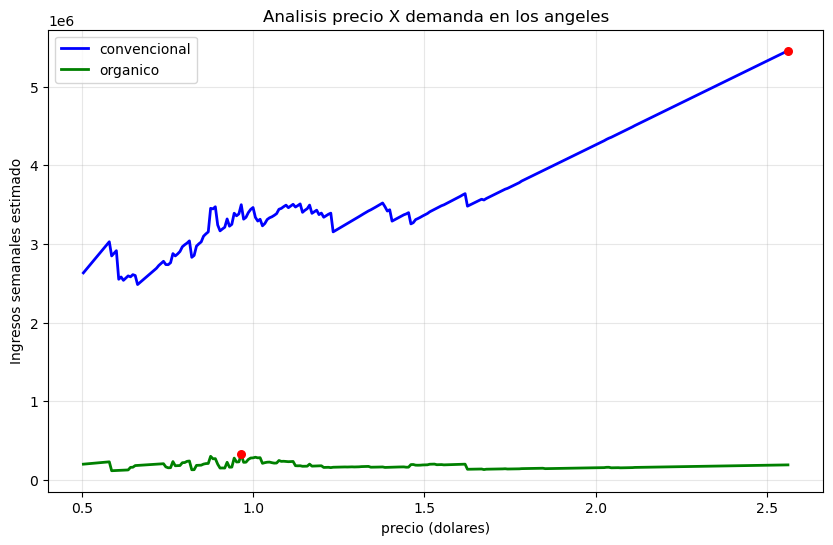

In [63]:
df_historia = pd.read_csv(DATA_PATH)
df_la = df_historia[df_historia['region'] == 'LosAngeles'] 

precio_min_real = df_la['AVGPrice'].min()
precio_max_real = df_la['AVGPrice'].max()

print(f"\nprecio maximo registrado ${precio_max_real:.2f}")
print(f"precio minimo registrado ${precio_min_real:.2f}")

# 300 precios simnulados entre 95% del minimo y 105% del maximo
precios = np.linspace(precio_min_real * 0.95,precio_max_real * 1.05, 300)

#inventar escenarios 
escenario_conv = pd.DataFrame({'AVGPrice': precios,'month': 7,'year': 2018,'week': 28,'type_organic': 0 })
escenario_org = pd.DataFrame({'AVGPrice': precios,'month': 7,'year': 2018,'week': 28,'type_organic': 1 })

# predecir demanda
escenario_conv['Vol_pred'] = model.predict(escenario_conv)
escenario_org['Vol_pred'] = model.predict(escenario_org)

# calcular ingreso precioXvolumen
escenario_conv['ingresos'] = escenario_conv['AVGPrice'] * escenario_conv['Vol_pred']
escenario_org['ingresos'] = escenario_org['AVGPrice'] * escenario_org['Vol_pred']

def optimo(df, nombre):
    mejor = df.loc[df['ingresos'].idxmax()]
    print(f"\nTipo {nombre}")
    print(f"precio optimo: ${mejor['AVGPrice']:.2f}")
    print(f"ventas estimadas: {mejor['Vol_pred']:,.0f}")
    print(f"ingresos semanales proyectados: ${mejor['ingresos']:,.2f}")

optimo(escenario_conv, "convencional")
optimo(escenario_org, "organico")

plt.figure(figsize=(10, 6))
plt.plot(escenario_conv['AVGPrice'], escenario_conv['ingresos'], label='convencional', color='blue', linewidth=2)
plt.plot(escenario_org['AVGPrice'], escenario_org['ingresos'], label='organico', color='green', linewidth=2)

# puntos optimos
mejor_conv = escenario_conv.loc[escenario_conv['ingresos'].idxmax()]
mejor_org = escenario_org.loc[escenario_org['ingresos'].idxmax()]

plt.scatter(mejor_conv['AVGPrice'], mejor_conv['ingresos'], color='red', s=30, zorder=5)
plt.scatter(mejor_org['AVGPrice'], mejor_org['ingresos'], color='red', s=30, zorder=5)

plt.title(f'Analisis precio X demanda en los angeles')
plt.xlabel('precio (dolares)')
plt.ylabel('Ingresos semanales estimado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


el punto optimo para convencional se ve extraño

comprobar elasticidad en un rango alto de precio

In [64]:
test_bajo = pd.DataFrame({'AVGPrice': [2.20],'month': [7],'year': [2018],'week': [28],'type_organic': [0]})
test_alto = pd.DataFrame({'AVGPrice': [2.50],'month': [7],'year': [2018],'week': [28],'type_organic': [0]})

vol_bajo = model.predict(test_bajo)[0]
vol_alto = model.predict(test_alto)[0]

cambio_precio = ((2.50 - 2.20) / 2.20) * 100
cambio_vol = ((vol_alto - vol_bajo) / vol_bajo) * 100
elasticidad_alta = cambio_vol / cambio_precio

print(f"rango alto")
print(f"${2.20:.2f} = {vol_bajo:,.0f} unidades")
print(f"${2.50:.2f} = {vol_alto:,.0f} unidades")
print(f"elasticidad: {elasticidad_alta:.2f}")

rango alto
$2.20 = 2,130,516 unidades
$2.50 = 2,130,234 unidades
elasticidad: -0.00


Al simular con precios optimistas desde 0.50 hasta 2.56 el modelo predice volumenes casi identicos para precios mayores a 2.20 y provoca que el precio optimo sea 2.56 que es el limite maximo simulado, por lo que el modelo no encontro un punto optimo real y siguio subiendo hasta donde terminaba la simulacion creyendo que aumentar el precio no provocaria que la demanda bajara, esto se ve en el volumen predecido para los precios de 2.20 y 2.50

Esto puede ser por que el modelo fue entrenado principalmente con precios entre 0.75 y 1.75  y los precios mayores a estos eran valores atipicos que se daban en ciertas fechas,esto comprobado en el notebook de exploracion, y cuando se le pide predecir en precios muy altos como 2.50 el modelo esta extrapolando fuera de su rango de conocimiento y predice valores constantes en lugar de seguir la ley de demanda

In [65]:
# distribucion de precios en train
df_train = df_la[df_la['Date'] < '2018-01-01']
print(f"\ndistribucion de precios en 2015-2017")
print(f"precio promedio: ${df_train['AVGPrice'].mean():.2f}")
print(f"precio minimo: ${df_train['AVGPrice'].min():.2f}")
print(f"precio maximo: ${df_train['AVGPrice'].max():.2f}")

# rango donde esta concentrada la mayoria de datos con percentiles 15-85
precio_p15 = df_train['AVGPrice'].quantile(0.15)
precio_p85 = df_train['AVGPrice'].quantile(0.85)

print(f"\nrango de concentracion de datos (percentil 15-85):")
print(f"desde: ${precio_p15:.2f}")
print(f"hasta: ${precio_p85:.2f}")



distribucion de precios en 2015-2017
precio promedio: $1.21
precio minimo: $0.53
precio maximo: $2.44

rango de concentracion de datos (percentil 15-85):
desde: $0.84
hasta: $1.60


Se confirma que el precio promedio esta entre 0.75 y 1.75 ya que el promedio es 1.21, lo mejor sera usar percentiles para evitarse los valores atipico ya que en el notebook de exploracion se comprobo que estos valores siempre se dan entre septiembre y octubre y aqui se quiere predecir para julio

Para solucionar esto se limita la simulacion a precios entre percentil 15 y 85 que es el rango donde el modelo vio suficientes datos durante el entrenamiento y donde la elasticidad deberia funcionar correctamente,al limitar el rango  el modelo ya no extrapola fuera de lo que conoce y puede encontrar el precio que maximiza ingresos de forma confiable



precio minimo: $0.84
precio maximo: $1.63

Tipo convencional
precio optimo: $1.62
ventas estimadas: 2,248,197
ingresos semanales proyectados: $3,638,835.07

Tipo organico
precio optimo: $0.97
ventas estimadas: 333,428
ingresos semanales proyectados: $322,606.92


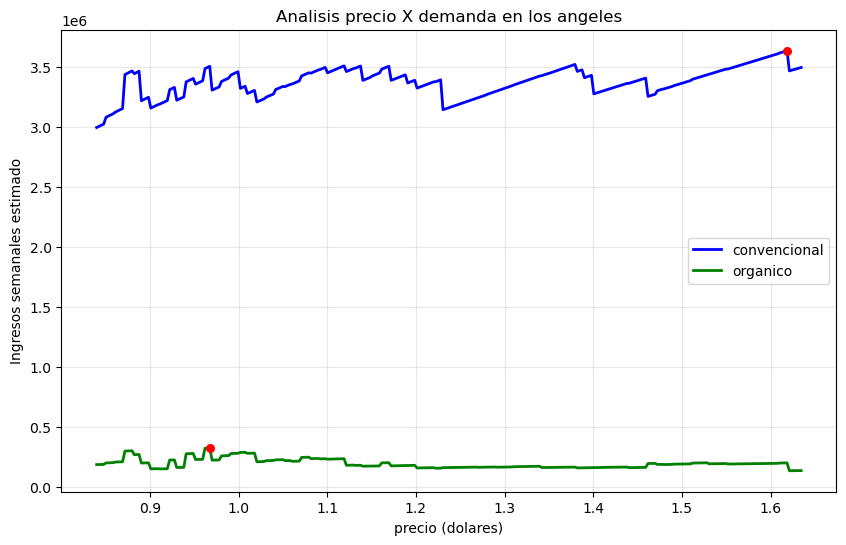

In [66]:
df_historia = pd.read_csv(DATA_PATH)
df_la = df_historia[df_historia['region'] == 'LosAngeles']

precio_min_real = df_la['AVGPrice'].quantile(0.15)  # Percentil 15
precio_max_real = df_la['AVGPrice'].quantile(0.85)  # Percentil 85 

print(f"\nprecio minimo: ${precio_min_real:.2f}")
print(f"precio maximo: ${precio_max_real:.2f}")

precios = np.linspace(precio_min_real, precio_max_real, 300)

escenario_conv = pd.DataFrame({'AVGPrice': precios, 'month': 7, 'year': 2018, 'week': 28, 'type_organic': 0})
escenario_org = pd.DataFrame({'AVGPrice': precios, 'month': 7, 'year': 2018, 'week': 28, 'type_organic': 1})

# predecir demanda
escenario_conv['Vol_pred'] = model.predict(escenario_conv)
escenario_org['Vol_pred'] = model.predict(escenario_org)

# calcular ingreso precioXvolumen
escenario_conv['ingresos'] = escenario_conv['AVGPrice'] * escenario_conv['Vol_pred']
escenario_org['ingresos'] = escenario_org['AVGPrice'] * escenario_org['Vol_pred']

def optimo(df, nombre):
    mejor = df.loc[df['ingresos'].idxmax()]
    print(f"\nTipo {nombre}")
    print(f"precio optimo: ${mejor['AVGPrice']:.2f}")
    print(f"ventas estimadas: {mejor['Vol_pred']:,.0f}")
    print(f"ingresos semanales proyectados: ${mejor['ingresos']:,.2f}")

optimo(escenario_conv, "convencional")
optimo(escenario_org, "organico")

plt.figure(figsize=(10, 6))
plt.plot(escenario_conv['AVGPrice'], escenario_conv['ingresos'], label='convencional', color='blue', linewidth=2)
plt.plot(escenario_org['AVGPrice'], escenario_org['ingresos'], label='organico', color='green', linewidth=2)

mejor_conv = escenario_conv.loc[escenario_conv['ingresos'].idxmax()]
mejor_org = escenario_org.loc[escenario_org['ingresos'].idxmax()]

plt.scatter(mejor_conv['AVGPrice'], mejor_conv['ingresos'], color='red', s=30, zorder=5)
plt.scatter(mejor_org['AVGPrice'], mejor_org['ingresos'], color='red', s=30, zorder=5)

plt.title('Analisis precio X demanda en los angeles')
plt.xlabel('precio (dolares)')
plt.ylabel('Ingresos semanales estimado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ahora si el modelo logro predecir valores mas realistas,el precio optimo para palta convencional es $1.62 y para organica $0.97 durante el mes de julio,ambos precios estando dentro del rango simulado y no en bordes lo que confirma que son puntos optimos reales

### grafico interactivo

In [67]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=escenario_conv['AVGPrice'],
    y=escenario_conv['ingresos'],
    mode='lines',
    name='convencional',
    line=dict(color='#1f77b4', width=3)
))

fig.add_trace(go.Scatter(
    x=escenario_org['AVGPrice'],
    y=escenario_org['ingresos'],
    mode='lines',
    name='organico',
    line=dict(color='#2ca02c', width=3)
))

fig.add_trace(go.Scatter(
    x=[mejor_conv['AVGPrice']],
    y=[mejor_conv['ingresos']],
    mode='markers',
    name=f'optimo conv (${mejor_conv["AVGPrice"]:.2f})',
    marker=dict(color='red', size=14, symbol='circle', line=dict(width=2, color='white'))
))

fig.add_trace(go.Scatter(
    x=[mejor_org['AVGPrice']],
    y=[mejor_org['ingresos']],
    mode='markers',
    name=f'optimo org (${mejor_org["AVGPrice"]:.2f})',
    marker=dict(color='orange', size=14, symbol='circle', line=dict(width=2, color='white'))
))

fig.update_layout(
    title='Optimizacion de ingresos para los angeles',
    xaxis_title='precio (dolares)',
    yaxis_title='ingreso semanal proyectado',
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    height=600
)

fig.update_yaxes(tickprefix="$", tickformat=",.")
fig.show()

### Estimacion de demanda X precio

In [68]:
fig_demanda = go.Figure()

fig_demanda.add_trace(go.Scatter(
    x=escenario_conv['AVGPrice'],
    y=escenario_conv['Vol_pred'],
    mode='lines',
    name='demanda convencional (unidades)',
    line=dict(color='blue', width=3)
))

fig_demanda.add_trace(go.Scatter(
    x=escenario_org['AVGPrice'],
    y=escenario_org['Vol_pred'],
    mode='lines',
    name='demanda organica (unidades)',
    line=dict(color='green', width=3)
))

fig_demanda.update_layout(
    title='curva de demanda',
    xaxis_title='precio (dolares)',
    yaxis_title='volumen de ventas semanales (demanda)',
    hovermode="x unified",
    template="plotly_white"
)

fig_demanda.show()

La demanda de la palta convencional muestra una elasticidad precio-demanda negativa pues en precios bajos cercanos a 0.85 alcanza cerca de 4 millones de unidades semanales y disminuye hasta 2.4 millones en $1.62 como ya se comprobo arriba, la caida es fuerte y seguida entre $0.85 y $1.20 lo que indica alta sensibilidad del consumidor en ese rango pero despues de $1.20 la curva se aplana mostrando que los compradores restantes son menos sensibles al precio

Para las paltas organicas la demanda se mantiene constante sin importar el precio lo que indica elasticidad casi nula, probablemente por que los consumidores de las paltas organicas valoran este producto por razones externas como pueden ser certificacion de salud o sostenibilidad por encima del precio,este comportamiento es tipico de productos premium donde los compradores tienen una disposicion a pagar independiente del precio
